In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print('All libriries imported successfully!')

All libriries imported successfully!


In [2]:
# Loading dataset
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# First look at the data
print("Shape:", df.shape)
print("First 5 rows:")
df.head()

Shape: (10000, 12)
First 5 rows:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Basic information about dataset
print('Dataset info:')
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nChurn distribution:')
print(df['churn'].value_counts())
print('\nChurn rate:', round(df['churn'].mean()*100, 2), '%')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
ba

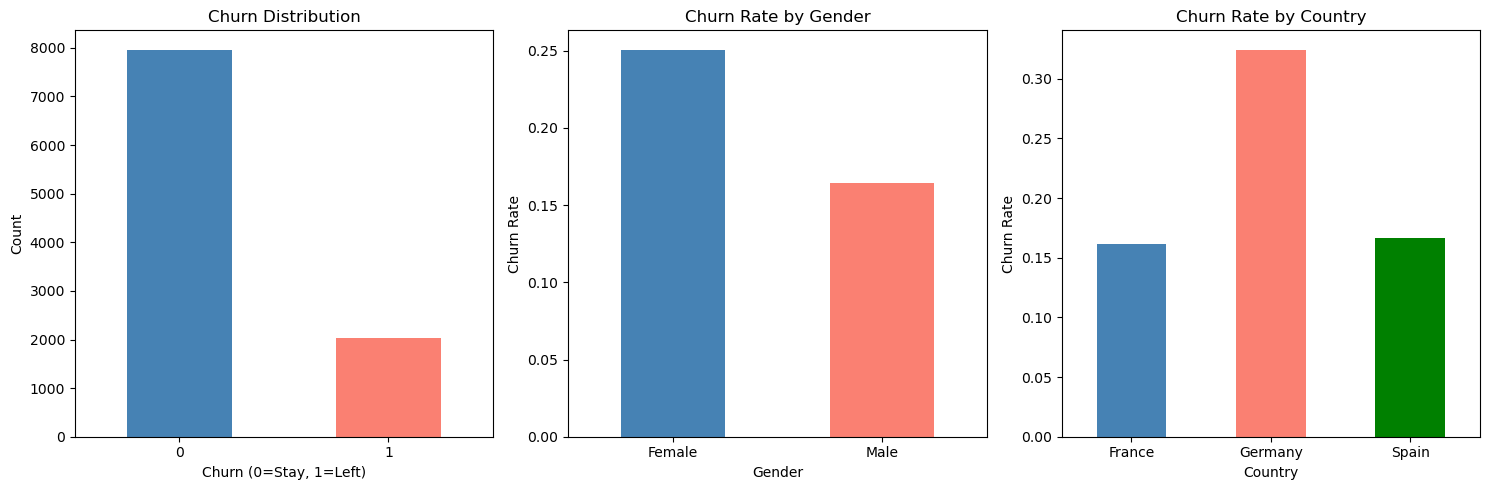

In [6]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Churn count
df['churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Churn Distribution')
axes[0].set_xlabel('Churn (0=Stay, 1=Left)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Churn by gender
df.groupby('gender')['churn'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Churn Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(rotation=0)

# Churn by country
df.groupby('country')['churn'].mean().plot(kind='bar', ax=axes[2], color=['steelblue', 'salmon', 'green'])
axes[2].set_title('Churn Rate by Country')
axes[2].set_xlabel('Country')
axes[2].set_ylabel('Churn Rate')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.show()

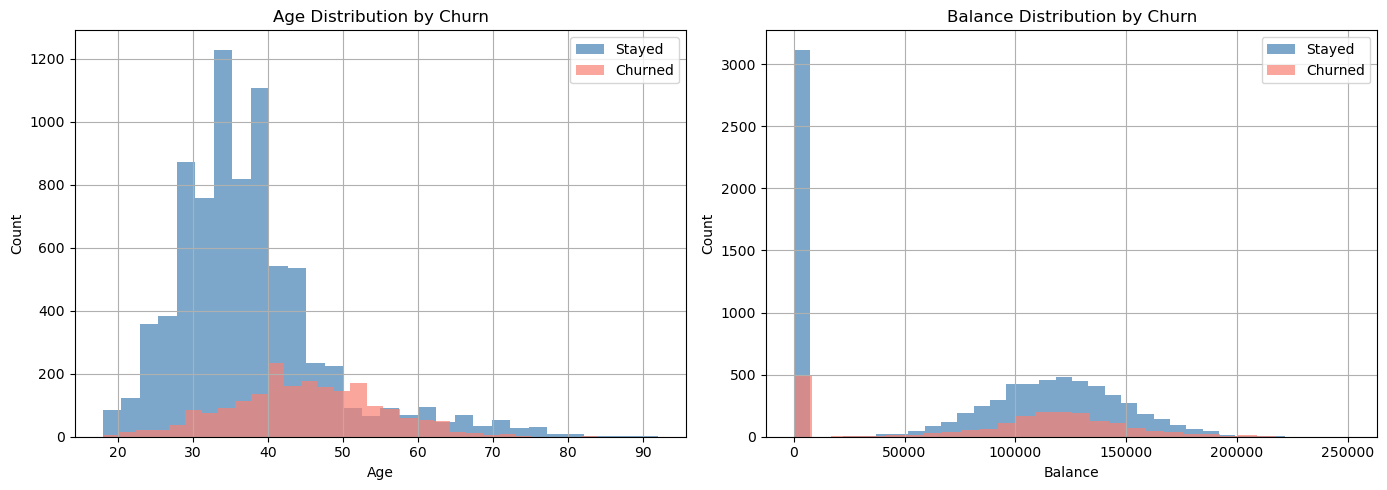

In [8]:
# Age and balance analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by churn
df[df['churn']==0]['age'].hist(bins=30, ax=axes[0], alpha=0.7, color='steelblue', label="Stayed")
df[df['churn']==1]['age'].hist(bins=30, ax=axes[0], alpha=0.7, color='salmon', label='Churned')
axes[0].set_title('Age Distribution by Churn')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Balance distribution by churn
df[df['churn']==0]['balance'].hist(bins=30, ax=axes[1], alpha=0.7, color='steelblue', label='Stayed')
df[df['churn']==1]['balance'].hist(bins=30, ax=axes[1], alpha=0.7, color='salmon', label='Churned')
axes[1].set_title('Balance Distribution by Churn')
axes[1].set_xlabel('Balance')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Data Preprocessing

# drop customer_id column
df_ml = df.drop('customer_id', axis=1)

# encode categorical variables
le = LabelEncoder()
df_ml['gender'] = le.fit_transform(df_ml['gender'])
df_ml['country'] = le.fit_transform(df_ml['country'])

print('After encoding:')
print(df_ml[['gender', 'country']].head())
print('\nGender values:', df_ml['gender'].unique())
print("Country values:", df_ml['country'].unique())

After encoding:
   gender  country
0       0        0
1       0        2
2       0        0
3       0        0
4       0        2

Gender values: [0 1]
Country values: [0 2 1]


In [13]:
# Split features and target
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('\nTraining set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data preprocessing complete.')

Features shape: (10000, 10)
Target shape: (10000,)

Training set size: 8000
Testing set size: 2000
Data preprocessing complete.


In [15]:
# Logistic Regression - Baseline Model

print('Training Logistic Regression')
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test_scaled)

# Evalutaion
print('\nLogistic Regression Results')
print(f"\nAccuracy: {accuracy_score(y_test, lr_predictions)*100:.2f}%")
print('\nClassification Report')
print(classification_report(y_test, lr_predictions))

Training Logistic Regression

Logistic Regression Results

Accuracy: 80.50%

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000



In [16]:
# Random Forest Model

print('Training Random Forest')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
print('\nRandom Forest Results')
print(f'Accuracy:{accuracy_score(y_test, rf_predictions)*100:.2f}%')
print('\nClassification Report')
print(classification_report(y_test, rf_predictions))

Training Random Forest

Random Forest Results
Accuracy:85.70%

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1593
           1       0.76      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



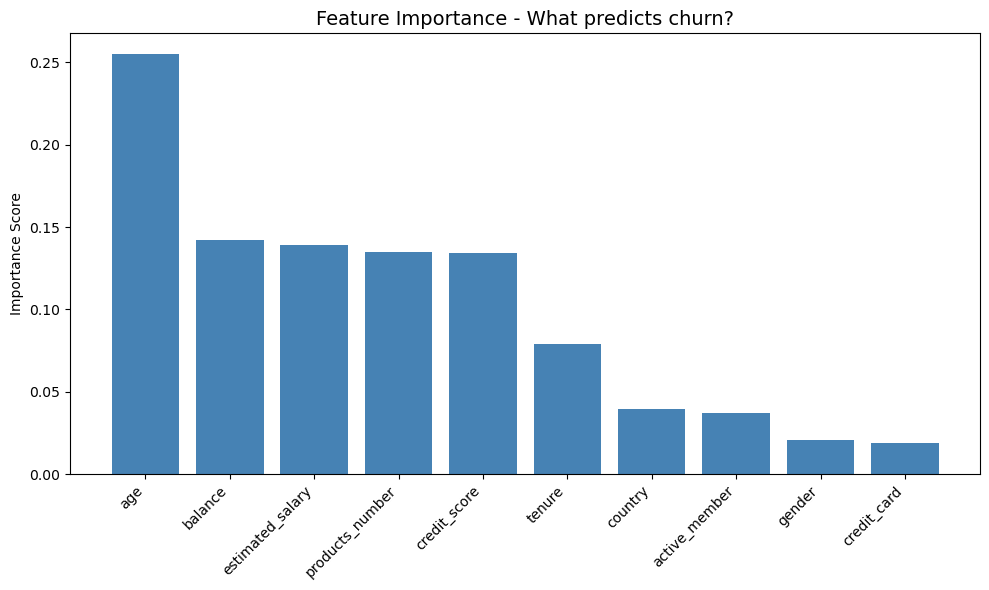


Feature Rankings:
1.age: 0.2549
2.balance: 0.1423
3.estimated_salary: 0.1390
4.products_number: 0.1347
5.credit_score: 0.1340
6.tenure: 0.0789
7.country: 0.0394
8.active_member: 0.0371
9.gender: 0.0205
10.credit_card: 0.0192


In [18]:
# Feature Importance
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance - What predicts churn?", fontsize = 14)
plt.bar(range(len(feature_names)),importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Rankings:')
for i in range(len(feature_names)):
    print(f"{i+1}.{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")